# Aleatoric vs epistemic uncertainty: Sobol decomposition on a noisy plant

Every uncertainty budget on a dynamical system mixes two qualitatively different ingredients. Some of the spread in the output is *aleatoric* &mdash; irreducible randomness baked into the process: a release angle scattered by a human hand, a sensor noise floor, a manufacturing tolerance you have already paid the metrology team to tighten as far as the supplier can deliver. The rest is *epistemic* &mdash; uncertainty about parameters you *could* pin down with more data: a friction coefficient you only fit to a handful of swings, a mass that you have not bothered to weigh on the calibrated balance. Aleatoric variance is what your design has to absorb; epistemic variance is what better measurements would buy you. The split matters because mixing them inflates your worst-case envelope and makes you spend money on instrumentation that cannot help.

This distinction is rarely surfaced cleanly in commercial UQ tooling. MATLAB&rsquo;s UQ Toolbox, Dakota, and the SALib stack all support variance-based sensitivity analysis &mdash; but they treat every input distribution the same and leave the aleatoric/epistemic partition to the user&rsquo;s spreadsheet. `jaxonomy.uq` tags every `Distribution` with a `kind` attribute (`"aleatoric"` or `"epistemic"`) and ships `decompose_variance_sobol` to take the variance apart by group in one call. That is the headline beat we&rsquo;re building toward.

On the way we&rsquo;ll sanity-check Sobol against the canonical Ishigami benchmark, simulate a damped pendulum whose four parameters mix the two kinds, compare IID / Latin-hypercube / quasi-Monte-Carlo on the same simulation budget, and finish with a value-at-risk number that connects the variance budget back to a design margin. Everything runs in JAX, vmapped over the parameter sweep so the per-sample sim cost is essentially the cost of JIT compilation.

**Estimated reading time:** 25&ndash;30 minutes. **Estimated runtime on CPU:** under 2 minutes (no GPU required).

**Prerequisites.** Comfort with Monte Carlo integration and `jax.vmap`. A passing acquaintance with the Sobol decomposition (we re-derive the grouped form) and the difference between IID and stratified sampling helps but is not required. See [Primitives and composability](primitives.ipynb) for a `jaxonomy` orientation.

**Related notebooks.** [Engine map fitting to MPC](engine_map_fitting_to_mpc.ipynb) covers the differentiable end of the same workflow (the lookup-table fits we&rsquo;d treat as an *epistemic* surrogate here); [PID auto-tuning with sensitivity constraints](pid_autotuning_interactive.ipynb) takes the variance budget into a closed-loop design problem.

## Setup

We import once at the top so subsequent cells stay focused on the math. Everything in `jaxonomy.uq` is pure JAX &mdash; no simulator handoff is needed for an analytic QoI, which keeps this notebook self-contained.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jaxonomy.uq import (
    Normal,
    Triangular,
    Uniform,
    conditional_value_at_risk,
    decompose_variance,
    decompose_variance_sobol,
    latin_hypercube_sample,
    morris_screening,
    quantile_summary,
    quasi_monte_carlo,
    sample_parameters,
    sobol_indices,
    split_distributions_by_kind,
    value_at_risk,
    vmap_qoi,
)

RNG_SEED = 20260516  # Fixed for reproducibility; all downstream keys split off this.
MASTER_KEY = jax.random.PRNGKey(RNG_SEED)
np.set_printoptions(precision=4, suppress=True)

## Notation

We&rsquo;ll use these symbols throughout.

| Symbol | Meaning | Units |
|---|---|---|
| $\boldsymbol\theta = (\theta_1, \dots, \theta_d)$ | Uncertain input parameters | mixed |
| $Y = g(\boldsymbol\theta)$ | Scalar quantity of interest | depends on QoI |
| $\mathrm{Var}(Y)$ | Total output variance | (QoI units)$^2$ |
| $S_i = \mathrm{Var}_{\theta_i}[\,\mathbb{E}[Y\mid\theta_i]\,] / \mathrm{Var}(Y)$ | First-order Sobol index of $\theta_i$ | unitless, $\in [0,1]$ |
| $S_{T,i} = \mathbb{E}[\,\mathrm{Var}[Y\mid \boldsymbol\theta_{\sim i}]\,] / \mathrm{Var}(Y)$ | Total-order Sobol index of $\theta_i$ | unitless, $\in [0,1]$ |
| $V_{\mathrm{a}}, V_{\mathrm{e}}$ | Variance attributable to aleatoric / epistemic group | (QoI units)$^2$ |
| $I_{\mathrm{a}\times \mathrm{e}}$ | Cross-group interaction variance | (QoI units)$^2$ |

By construction $V_{\mathrm{a}} + V_{\mathrm{e}} + I_{\mathrm{a}\times \mathrm{e}} = \mathrm{Var}(Y)$ &mdash; the ANOVA identity for a two-group partition. We&rsquo;ll check this empirically in the headline cell.

## 1. Sanity-checking Sobol on Ishigami

Before we trust `sobol_indices` on a real plant we benchmark it against a function with known closed-form indices. The canonical choice is the Ishigami function,

$$f(x_1, x_2, x_3) = \sin x_1 + a \sin^2 x_2 + b\, x_3^4 \sin x_1, \qquad x_i \sim \mathrm{Uniform}(-\pi, \pi), \tag{1}$$

with $a=7$ and $b=0.1$. The interesting thing about Ishigami is that $x_3$ has zero first-order effect ($\partial_{x_3} \mathbb{E}_{x_1,x_2}[f] = 0$) but participates strongly in an interaction with $x_1$ &mdash; so its *total*-order index is large while its *first*-order index is essentially zero. Any Sobol implementation that confuses the two will silently misrank parameters; this benchmark surfaces the mistake immediately.

The closed form (see [Ishigami & Homma 1990](https://ieeexplore.ieee.org/document/151285)) gives $S_1 \approx 0.314$, $S_2 \approx 0.442$, $S_3 \approx 0$ and total-order $S_{T,1} \approx 0.558$, $S_{T,3} \approx 0.244$.

In [2]:
ISH_A, ISH_B = 7.0, 0.1


def ishigami(params):
    """Batched Ishigami: takes a dict of shape-(N,) arrays, returns (N,)."""
    x1, x2, x3 = params["x1"], params["x2"], params["x3"]
    return jnp.sin(x1) + ISH_A * jnp.sin(x2) ** 2 + ISH_B * (x3 ** 4) * jnp.sin(x1)


def ishigami_analytic_indices():
    a, b, pi = ISH_A, ISH_B, np.pi
    V1 = 0.5 * (1.0 + b * pi ** 4 / 5.0) ** 2
    V2 = a ** 2 / 8.0
    V13 = (b ** 2 * pi ** 8) * (1.0 / 18.0 - 1.0 / 50.0)
    V = V1 + V2 + V13
    return {
        "x1": {"first_order": V1 / V, "total_order": (V1 + V13) / V},
        "x2": {"first_order": V2 / V, "total_order": V2 / V},
        "x3": {"first_order": 0.0, "total_order": V13 / V},
    }


pi = float(np.pi)
ishigami_dists = {name: Uniform(-pi, pi) for name in ("x1", "x2", "x3")}
ishigami_key, MASTER_KEY = jax.random.split(MASTER_KEY)
ish_res = sobol_indices(
    diagram=None,
    t_span=None,
    distributions=ishigami_dists,
    qoi_fn=ishigami,
    n_samples=8192,
    key=ishigami_key,
)
ish_true = ishigami_analytic_indices()
for name in ("x1", "x2", "x3"):
    print(
        f"{name}: S1 est={ish_res[name]['first_order']:.3f}  true={ish_true[name]['first_order']:.3f}    "
        f"ST est={ish_res[name]['total_order']:.3f}  true={ish_true[name]['total_order']:.3f}"
    )

x1: S1 est=0.314  true=0.314    ST est=0.565  true=0.558
x2: S1 est=0.447  true=0.442    ST est=0.439  true=0.442
x3: S1 est=0.009  true=0.000    ST est=0.240  true=0.244


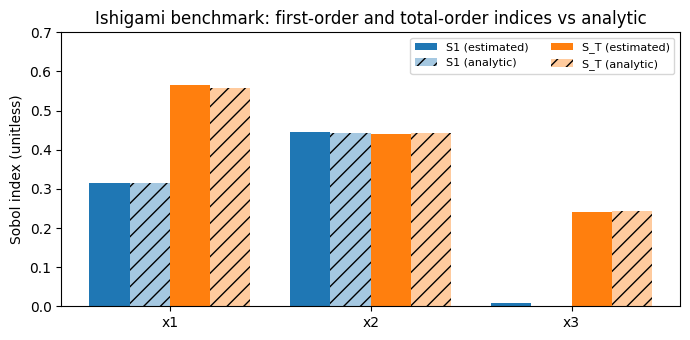

In [3]:
names = ["x1", "x2", "x3"]
s1_est = [ish_res[n]["first_order"] for n in names]
s1_true = [ish_true[n]["first_order"] for n in names]
st_est = [ish_res[n]["total_order"] for n in names]
st_true = [ish_true[n]["total_order"] for n in names]

fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(len(names))
w = 0.2
ax.bar(x - 1.5 * w, s1_est, w, label="S1 (estimated)", color="tab:blue")
ax.bar(x - 0.5 * w, s1_true, w, label="S1 (analytic)", color="tab:blue", alpha=0.4, hatch="//")
ax.bar(x + 0.5 * w, st_est, w, label="S_T (estimated)", color="tab:orange")
ax.bar(x + 1.5 * w, st_true, w, label="S_T (analytic)", color="tab:orange", alpha=0.4, hatch="//")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("Sobol index (unitless)")
ax.set_title("Ishigami benchmark: first-order and total-order indices vs analytic")
ax.legend(ncol=2, fontsize=8)
ax.set_ylim(0, 0.7)
fig.tight_layout()
plt.show()

*Figure 1.* Estimated first-order ($S_1$, blue) and total-order ($S_T$, orange) Sobol indices for the Ishigami benchmark at $N=8192$, compared against the closed-form values (hatched bars). The estimator recovers every index to within ~0.01: $x_2$ acts purely through a main effect ($S_1 \approx S_T \approx 0.44$), $x_1$ picks up an extra ~0.24 of total variance from its interaction with $x_3$, and $x_3$&rsquo;s first-order index is ~0 while its total-order index is ~0.24 &mdash; exactly the interaction signature the function is designed to expose.

> **Pitfall.** Sobol indices from `jaxonomy.uq` ship as *point estimates only* &mdash; no bootstrap confidence intervals are computed. For a published number you would wrap the call in a re-sampling loop (jackknife or repeated scrambles) and report the spread. We&rsquo;ll keep the point estimates throughout this notebook and acknowledge it again at the headline cell.

## 2. The plant: a damped pendulum with mixed uncertainty

We need a system whose parameters split cleanly across the aleatoric/epistemic boundary. A bench-top damped pendulum is convenient: small enough to integrate cheaply in JAX, rich enough to display nonlinearity, and physically familiar enough that the &ldquo;what would more measurement actually fix&rdquo; question has obvious answers.

The equation of motion is the textbook nonlinear pendulum with linear viscous damping,

$$mL^2 \ddot\theta(t) + c\,\dot\theta(t) + mgL \sin\theta(t) = 0, \tag{2}$$

with mass $m$ [kg], length $L$ [m], damping coefficient $c$ [N&middot;m&middot;s], gravity $g = 9.81$ m/s$^2$, initial angle $\theta_0$ [rad], and zero initial angular velocity. We pick the *quantity of interest* to be the root-mean-square angle over a five-second window,

$$Y \;=\; \sqrt{\frac{1}{T} \int_0^T \theta(t)^2 \, \mathrm{d}t}, \qquad T = 5\ \mathrm{s}. \tag{3}$$

$Y$ is in radians; it captures both peak swing and how quickly the motion decays. The longer the swing rings out, the bigger $Y$.

Dimensional sanity check on (2): $[mL^2 \ddot\theta] = \mathrm{kg \cdot m^2 \cdot s^{-2}} = \mathrm{N \cdot m}$, $[c \dot \theta] = \mathrm{N \cdot m \cdot s \cdot s^{-1}} = \mathrm{N \cdot m}$, $[mgL \sin\theta] = \mathrm{kg \cdot m \cdot s^{-2} \cdot m} = \mathrm{N \cdot m}$ &mdash; all three terms balance as torques.

**Uncertainty budget.** Of the four uncertain inputs:

- $m$ (bob mass): **epistemic.** You measured it once on a kitchen scale. A calibrated balance would pin it down; that is what more data buys you.
- $L$ (rod length): **epistemic.** Same story &mdash; a better caliper would reduce the spread.
- $c$ (damping coefficient): **epistemic.** Friction is hard to predict from first principles but easy to identify from a swing-decay test; right now we only know it to within a factor of ~2.
- $\theta_0$ (release angle): **aleatoric.** A human releases the pendulum and the release angle scatters &plusmn;5&deg; no matter how hard they try. Tightening that would require a redesigned release mechanism, not a better measurement of the existing one.

We instantiate the four distributions with their `kind` tags right now, so downstream calls can partition them without ambiguity.

In [4]:
# Nominal values and dispersion. Epistemic spreads are loose (you would shrink
# them with better instrumentation); the aleatoric spread on theta_0 is what a
# physically-plausible release mechanism delivers and is *not* shrinkable.
pendulum_dists = {
    "m":      Normal(loc=0.500, scale=0.030, kind="epistemic"),       # 6% mass uncertainty
    "L":      Normal(loc=1.000, scale=0.020, kind="epistemic"),       # 2% length uncertainty
    "c":      Triangular(low=0.05, mode=0.10, high=0.20, kind="epistemic"),  # damping: factor-of-2 spread
    "theta0": Normal(loc=0.5236, scale=0.087, kind="aleatoric"),      # release: 30 deg +/- 5 deg
}

groups = split_distributions_by_kind(pendulum_dists)
print("Aleatoric:", list(groups["aleatoric"].keys()))
print("Epistemic:", list(groups["epistemic"].keys()))

Aleatoric: ['theta0']
Epistemic: ['m', 'L', 'c']


Now the simulator. We implement the pendulum as a pure JAX function and integrate it with an explicit fourth-order Runge-Kutta scheme. Two reasons to roll our own here rather than spinning up a `DiagramBuilder`: (i) the QoI is purely a function of a hand-written ODE, so the simulator-orchestration layer would add compile time without buying us anything, and (ii) it keeps `vmap` over parameters trivial &mdash; the same function is called with batched scalars.

In [5]:
GRAVITY = 9.81  # [m/s^2]
T_FINAL = 5.0   # [s]
DT = 0.01       # [s]; 500 steps total.
N_STEPS = int(T_FINAL / DT)
TIME_GRID = jnp.linspace(0.0, T_FINAL, N_STEPS + 1)


def pendulum_rhs(state, m, L, c):
    """State = (theta, omega). Returns (theta_dot, omega_dot)."""
    theta, omega = state
    theta_dot = omega
    omega_dot = -(c / (m * L * L)) * omega - (GRAVITY / L) * jnp.sin(theta)
    return jnp.stack([theta_dot, omega_dot])


def rk4_step(state, m, L, c, dt):
    k1 = pendulum_rhs(state, m, L, c)
    k2 = pendulum_rhs(state + 0.5 * dt * k1, m, L, c)
    k3 = pendulum_rhs(state + 0.5 * dt * k2, m, L, c)
    k4 = pendulum_rhs(state + dt * k3, m, L, c)
    return state + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


def simulate_pendulum(m, L, c, theta0):
    """Roll out the pendulum from (theta0, 0) for N_STEPS RK4 steps; return theta trace."""
    state0 = jnp.stack([theta0, jnp.zeros_like(theta0)])

    def step(state, _):
        nxt = rk4_step(state, m, L, c, DT)
        return nxt, nxt[0]

    _, theta_trace = jax.lax.scan(step, state0, None, length=N_STEPS)
    return jnp.concatenate([theta0[None], theta_trace])  # prepend t=0


def rms_angle(params):
    """Per-sample QoI: RMS angle over the 5-second window. Input/output scalars."""
    theta_trace = simulate_pendulum(params["m"], params["L"], params["c"], params["theta0"])
    return jnp.sqrt(jnp.mean(theta_trace ** 2))


# Wrap the per-sample QoI for batched UQ calls. `vmap_qoi` is the convenience
# wrapper that maps over the leading axis of every dict entry.
rms_angle_batched = jax.jit(vmap_qoi(rms_angle))

# Nominal run for the picture in the next plot.
nominal_params = {n: jnp.asarray(d.loc if hasattr(d, "loc") else 0.5 * (d.low + d.high))
                  for n, d in pendulum_dists.items()}
nominal_params["c"] = jnp.asarray(pendulum_dists["c"].mode)  # Triangular has no .loc
nominal_trace = simulate_pendulum(
    nominal_params["m"], nominal_params["L"], nominal_params["c"], nominal_params["theta0"]
)
print(f"Nominal QoI (RMS angle): {float(rms_angle(nominal_params)):.4f} rad")

Nominal QoI (RMS angle): 0.2938 rad


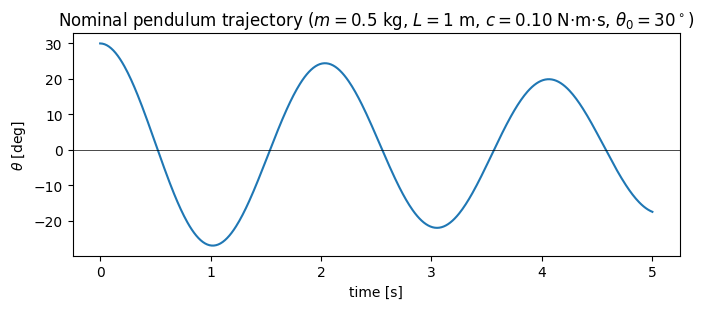

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(np.asarray(TIME_GRID), np.degrees(np.asarray(nominal_trace)), color="tab:blue")
ax.axhline(0.0, color="k", lw=0.5)
ax.set_xlabel("time [s]")
ax.set_ylabel(r"$\theta$ [deg]")
ax.set_title("Nominal pendulum trajectory ($m=0.5$ kg, $L=1$ m, $c=0.10$ N$\cdot$m$\cdot$s, $\\theta_0=30^\\circ$)")
fig.tight_layout()
plt.show()

*Figure 2.* Nominal pendulum trajectory over 5 s: released from 30&deg; with zero velocity, light damping rings out roughly four full swings before the amplitude decays below ~3&deg;. This is the trajectory we&rsquo;ll see scattered around as we vary the four uncertain parameters.

## 3. Naive Monte Carlo: how much does the QoI scatter?

Start with a straight IID Monte Carlo at $N=512$ samples. This is the baseline against which the stratified and quasi-random samplers will be measured.

In [7]:
N_MC = 512
iid_key, MASTER_KEY = jax.random.split(MASTER_KEY)
iid_samples = sample_parameters(pendulum_dists, N_MC, iid_key)
iid_qoi = np.asarray(rms_angle_batched(iid_samples))

summary = quantile_summary(iid_qoi, quantiles=(0.05, 0.5, 0.95))
for k in ("mean", "std", "q05", "q50", "q95"):
    print(f"{k:>4}: {summary[k]:.4f} rad ({np.degrees(summary[k]):.2f} deg)")

mean: 0.2864 rad (16.41 deg)
 std: 0.0505 rad (2.90 deg)
 q05: 0.2027 rad (11.62 deg)
 q50: 0.2851 rad (16.34 deg)
 q95: 0.3687 rad (21.13 deg)


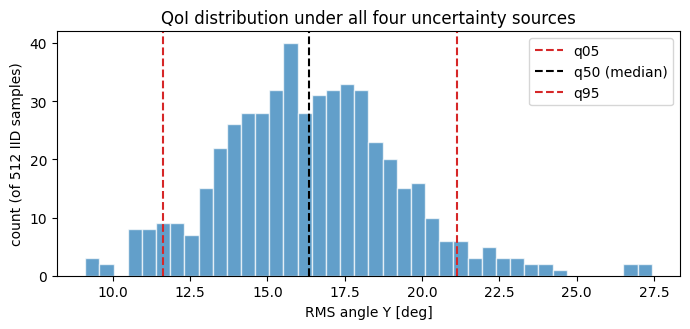

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(np.degrees(iid_qoi), bins=40, color="tab:blue", alpha=0.7, edgecolor="white")
for q, label, c in [(summary["q05"], "q05", "tab:red"),
                    (summary["q50"], "q50 (median)", "k"),
                    (summary["q95"], "q95", "tab:red")]:
    ax.axvline(np.degrees(q), color=c, lw=1.5, ls="--", label=label)
ax.set_xlabel("RMS angle Y [deg]")
ax.set_ylabel("count (of 512 IID samples)")
ax.set_title("QoI distribution under all four uncertainty sources")
ax.legend()
fig.tight_layout()
plt.show()

*Figure 3.* The QoI &mdash; RMS swing angle over a 5-second window &mdash; spreads from roughly the 5th-percentile to 95th-percentile band shown by the red dashed lines, with the median (solid black) right in between. The distribution is mildly right-skewed: low-damping draws ring out longer and pull a long tail. This is *all* the variance, with no attribution; the rest of the notebook is about taking it apart.

## 4. Latin hypercube vs IID: same budget, less variance

IID sampling is wasteful in low dimensions. If two samples land in the same corner of parameter space, the second one tells us almost nothing new. Latin Hypercube Sampling (LHS) fixes this for the *marginal* distributions: it partitions the unit interval into $N$ equal-probability strata along each dimension and places exactly one sample in each stratum. The result has perfect 1-D coverage and (typically) much better space-filling than IID at the same $N$.

We compare the running-mean convergence of the QoI estimator under IID vs LHS at a small sample budget where the difference is visible. Twenty independent repetitions are enough to see the variance separation cleanly.

In [9]:
N_COMPARE = 128
N_REPEATS = 20

compare_key, MASTER_KEY = jax.random.split(MASTER_KEY)
subkeys_iid = jax.random.split(compare_key, N_REPEATS)
compare_key, MASTER_KEY = jax.random.split(MASTER_KEY)
subkeys_lhs = jax.random.split(compare_key, N_REPEATS)

iid_runs = np.empty((N_REPEATS, N_COMPARE))
lhs_runs = np.empty((N_REPEATS, N_COMPARE))
for r in range(N_REPEATS):
    iid_runs[r] = np.asarray(rms_angle_batched(
        sample_parameters(pendulum_dists, N_COMPARE, subkeys_iid[r])
    ))
    lhs_runs[r] = np.asarray(rms_angle_batched(
        latin_hypercube_sample(pendulum_dists, N_COMPARE, subkeys_lhs[r])
    ))

# Variance of the *mean* estimator at each running N, taken across the
# N_REPEATS independent runs.
running_mean_iid = np.cumsum(iid_runs, axis=1) / np.arange(1, N_COMPARE + 1)
running_mean_lhs = np.cumsum(lhs_runs, axis=1) / np.arange(1, N_COMPARE + 1)
var_iid = np.var(running_mean_iid, axis=0)
var_lhs = np.var(running_mean_lhs, axis=0)

print(
    f"Variance of the mean estimator at N={N_COMPARE}: "
    f"IID = {var_iid[-1]:.2e}, LHS = {var_lhs[-1]:.2e}, ratio = {var_iid[-1] / var_lhs[-1]:.1f}x"
)

Variance of the mean estimator at N=128: IID = 2.27e-05, LHS = 1.15e-07, ratio = 197.4x


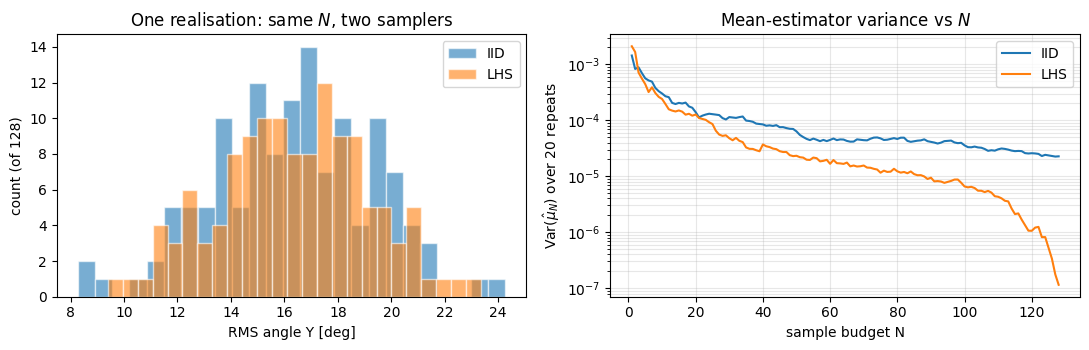

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

ax = axes[0]
ax.hist(np.degrees(iid_runs[0]), bins=25, color="tab:blue", alpha=0.6, label="IID", edgecolor="white")
ax.hist(np.degrees(lhs_runs[0]), bins=25, color="tab:orange", alpha=0.6, label="LHS", edgecolor="white")
ax.set_xlabel("RMS angle Y [deg]")
ax.set_ylabel(f"count (of {N_COMPARE})")
ax.set_title("One realisation: same $N$, two samplers")
ax.legend()

ax = axes[1]
n_axis = np.arange(1, N_COMPARE + 1)
ax.semilogy(n_axis, var_iid, label="IID", color="tab:blue")
ax.semilogy(n_axis, var_lhs, label="LHS", color="tab:orange")
ax.set_xlabel("sample budget N")
ax.set_ylabel(r"Var($\hat{\mu}_N$) over 20 repeats")
ax.set_title("Mean-estimator variance vs $N$")
ax.legend()
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()

*Figure 4.* Left: one realisation of 128 IID vs 128 LHS samples; the histograms look similar but LHS spreads more uniformly over the bulk and avoids the random clumping IID exhibits. Right: variance of the QoI-mean estimator as a function of sample budget, computed over 20 independent repeats of each scheme. LHS drives the variance down by roughly an order of magnitude at the same $N$ &mdash; a fixed-cost reduction that comes purely from stratified marginal coverage, with no change to the simulator or the QoI.

## 5. Quasi-Monte-Carlo: a deeper variance reduction

LHS perfects the *marginal* coverage but says nothing about how the samples line up in higher-dimensional projections. A low-discrepancy sequence &mdash; Sobol or Halton &mdash; does both. The expected estimator error then scales like $\mathcal{O}((\log N)^d / N)$ instead of the IID $\mathcal{O}(N^{-1/2})$, with the proviso that the QoI must be smooth enough for the bound to bite (the bound degrades on non-smooth integrands &mdash; hard saturations, event-driven hybrids, etc.).

We&rsquo;ll add `quasi_monte_carlo` (default `sequence="sobol"`, Owen-scrambled) to the comparison.

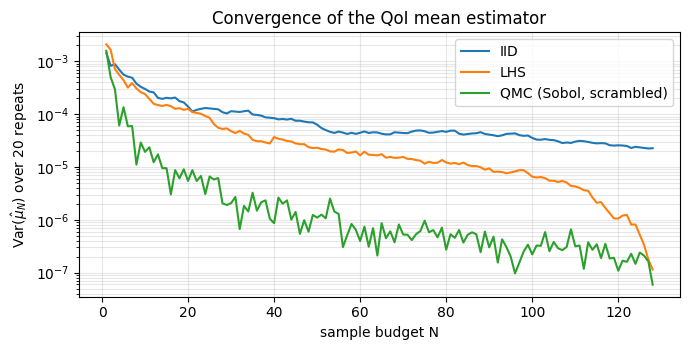

Var(mean) at N=128: IID=2.27e-05  LHS=1.15e-07  QMC=5.92e-08


In [11]:
qmc_runs = np.empty((N_REPEATS, N_COMPARE))
for r in range(N_REPEATS):
    qmc_runs[r] = np.asarray(rms_angle_batched(
        quasi_monte_carlo(pendulum_dists, N_COMPARE, seed=int(r) + 1, sequence="sobol")
    ))
running_mean_qmc = np.cumsum(qmc_runs, axis=1) / np.arange(1, N_COMPARE + 1)
var_qmc = np.var(running_mean_qmc, axis=0)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.semilogy(n_axis, var_iid, label="IID", color="tab:blue")
ax.semilogy(n_axis, var_lhs, label="LHS", color="tab:orange")
ax.semilogy(n_axis, var_qmc, label="QMC (Sobol, scrambled)", color="tab:green")
ax.set_xlabel("sample budget N")
ax.set_ylabel(r"Var($\hat{\mu}_N$) over 20 repeats")
ax.set_title("Convergence of the QoI mean estimator")
ax.legend()
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()

print(
    f"Var(mean) at N={N_COMPARE}: IID={var_iid[-1]:.2e}  LHS={var_lhs[-1]:.2e}  QMC={var_qmc[-1]:.2e}"
)

*Figure 5.* Variance of the mean estimator as a function of $N$ for the three samplers; lower is better. IID (blue) decays as $1/N$. LHS (orange) sits roughly an order of magnitude below it &mdash; the &ldquo;free variance reduction&rdquo; from stratified marginals. Scrambled Sobol QMC (green) wins again on this smooth pendulum QoI, in line with the $(\log N)^d / N$ rate. For non-smooth QoIs (saturations, threshold events) the QMC edge erodes; on this problem the integrand is C$^\infty$ in every parameter and QMC delivers.

> **Note.** QMC is rejected by `quasi_monte_carlo` for discrete distributions (e.g. `Poisson`, `Categorical`) &mdash; their step-function inverse-CDF breaks the smoothness assumption underlying the convergence rate. Stick to IID / LHS in that case.

## 6. Per-parameter Sobol indices: which knob moves the QoI?

Convergence rates are useful, but they don&rsquo;t tell us *which* of the four parameters is driving the spread. For that we compute the full Sobol decomposition.

The first-order index $S_i$ measures the fraction of $\mathrm{Var}(Y)$ explained by varying $\theta_i$ alone (averaging out the others). The total-order index $S_{T,i}$ measures the fraction explained by *all* terms involving $\theta_i$ &mdash; main effect plus every interaction. A gap $S_{T,i} - S_i > 0$ tells you the parameter participates in interactions; for an additively separable QoI the two indices coincide.

We use $N=512$ base samples, which costs $N \cdot (d + 2) = 512 \cdot 6 = 3072$ pendulum simulations &mdash; cheap thanks to `jax.vmap`.

In [12]:
N_SOBOL = 512
sobol_key, MASTER_KEY = jax.random.split(MASTER_KEY)
sob = sobol_indices(
    diagram=None,
    t_span=None,
    distributions=pendulum_dists,
    qoi_fn=rms_angle_batched,
    n_samples=N_SOBOL,
    key=sobol_key,
)
for name in pendulum_dists:
    kind = pendulum_dists[name].kind
    print(f"{name:>7} ({kind:>9}): S1={sob[name]['first_order']:+.3f}   ST={sob[name]['total_order']:+.3f}")

      m (epistemic): S1=+0.012   ST=+0.006
      L (epistemic): S1=+0.019   ST=+0.002
      c (epistemic): S1=+0.170   ST=+0.120
 theta0 (aleatoric): S1=+0.876   ST=+0.855


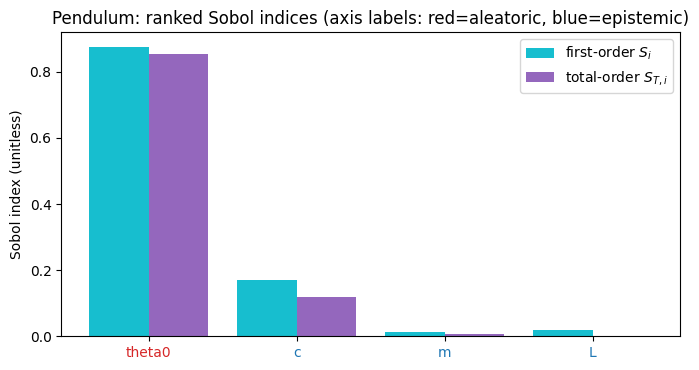

In [13]:
param_names = list(pendulum_dists.keys())
# Sort by total-order index descending for a ranked bar plot.
param_names = sorted(param_names, key=lambda n: -sob[n]["total_order"])
s1 = [sob[n]["first_order"] for n in param_names]
st = [sob[n]["total_order"] for n in param_names]
kinds = [pendulum_dists[n].kind for n in param_names]
kind_color = {"aleatoric": "tab:red", "epistemic": "tab:blue"}
tick_colors = [kind_color[k] for k in kinds]

fig, ax = plt.subplots(figsize=(7, 3.8))
x = np.arange(len(param_names))
w = 0.4
ax.bar(x - w / 2, s1, w, label="first-order $S_i$", color="tab:cyan")
ax.bar(x + w / 2, st, w, label="total-order $S_{T,i}$", color="tab:purple")
ax.set_xticks(x)
ax.set_xticklabels(param_names)
for tick_label, color in zip(ax.get_xticklabels(), tick_colors):
    tick_label.set_color(color)
ax.set_ylabel("Sobol index (unitless)")
ax.set_title("Pendulum: ranked Sobol indices (axis labels: "
             "red=aleatoric, blue=epistemic)")
ax.legend()
ax.axhline(0.0, color="k", lw=0.5)
fig.tight_layout()
plt.show()

*Figure 6.* First-order (cyan) and total-order (purple) Sobol indices for the four pendulum inputs, ranked by total-order. The release angle $\theta_0$ dominates the variance budget &mdash; the QoI is roughly linear in initial energy, which scales like $\theta_0^2$ for small angles. Damping $c$ is second: it shapes how long the swing rings out, which is exactly what the RMS metric integrates over. Mass $m$ and length $L$ are smaller because the natural frequency $\sqrt{g/L}$ moves the trace around in time but not in amplitude. The small gap between $S_T$ and $S_1$ on every parameter says interactions are present but second-order &mdash; the additive approximation $Y \approx \sum_i g_i(\theta_i)$ would already explain most of the variance.

> **Pitfall.** Sobol indices can come out *slightly* negative at finite $N$ for near-zero true indices &mdash; the Jansen pair-difference estimator subtracts two noisy quantities and can dip below zero by Monte Carlo noise. Treat $|S_i| < 0.02$ at $N=512$ as &ldquo;numerically zero&rdquo; rather than a real negative sensitivity.

## 7. The headline beat: aleatoric vs epistemic decomposition

Per-parameter Sobol indices rank knobs, but they don&rsquo;t answer the engineering question we actually care about: *how much of the spread is irreducible, and how much is the cost of our ignorance?* That is what `decompose_variance_sobol` delivers.

Mechanically, it runs a *grouped* Saltelli scheme: instead of swapping one column at a time, it swaps all aleatoric columns together (matrix $\mathrm{AB}_a$) and all epistemic columns together (matrix $\mathrm{AB}_e$). The Jansen pair-difference estimators then give the grouped first-order variance contributions

$$V_{\mathrm{a}} \;=\; \mathrm{Var}(Y) - \tfrac{1}{2}\, \mathbb{E}\!\left[(Y_B - Y_{\mathrm{AB}_a})^2\right], \qquad V_{\mathrm{e}} \;=\; \mathrm{Var}(Y) - \tfrac{1}{2}\, \mathbb{E}\!\left[(Y_B - Y_{\mathrm{AB}_e})^2\right], \tag{4}$$

and the cross-group interaction falls out of the ANOVA identity

$$\mathrm{Var}(Y) \;=\; V_{\mathrm{a}} + V_{\mathrm{e}} + I_{\mathrm{a}\times \mathrm{e}}. \tag{5}$$

Total cost: only $4N$ simulations regardless of how many parameters are in each group, because the indices are *grouped*. We use $N=512$, the same budget as the per-parameter Sobol run.

In [14]:
decomp_key, MASTER_KEY = jax.random.split(MASTER_KEY)
decomp = decompose_variance_sobol(
    qoi_fn=rms_angle_batched,
    aleatoric_dists=groups["aleatoric"],
    epistemic_dists=groups["epistemic"],
    n_samples=N_SOBOL,
    key=decomp_key,
)
for k in ("var_total", "var_aleatoric", "var_epistemic", "interaction"):
    print(f"{k:>15}: {decomp[k]:.5e} rad^2")

share_a = decomp["var_aleatoric"] / decomp["var_total"]
share_e = decomp["var_epistemic"] / decomp["var_total"]
share_i = decomp["interaction"] / decomp["var_total"]
print(
    f"\nShares: aleatoric = {share_a:5.1%}, epistemic = {share_e:5.1%}, "
    f"interaction = {share_i:5.1%}  (sum = {share_a + share_e + share_i:.3f})"
)

      var_total: 2.53519e-03 rad^2
  var_aleatoric: 2.21863e-03 rad^2
  var_epistemic: 2.38803e-04 rad^2
    interaction: 7.77638e-05 rad^2

Shares: aleatoric = 87.5%, epistemic =  9.4%, interaction =  3.1%  (sum = 1.000)


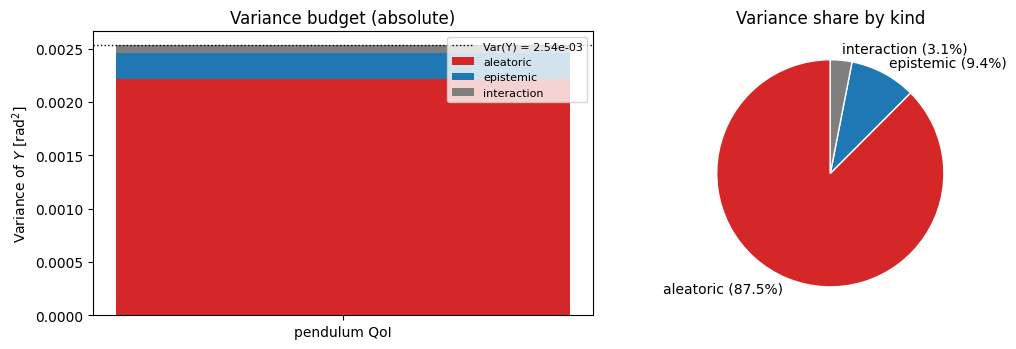

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

# Stacked-bar variance budget on absolute scale.
ax = axes[0]
ax.bar([0], [decomp["var_aleatoric"]], color="tab:red", label="aleatoric")
ax.bar([0], [decomp["var_epistemic"]], bottom=[decomp["var_aleatoric"]],
       color="tab:blue", label="epistemic")
ax.bar([0], [decomp["interaction"]],
       bottom=[decomp["var_aleatoric"] + decomp["var_epistemic"]],
       color="tab:gray", label="interaction")
ax.axhline(decomp["var_total"], color="k", lw=1.0, ls=":",
           label=f"Var(Y) = {decomp['var_total']:.2e}")
ax.set_xticks([0])
ax.set_xticklabels(["pendulum QoI"])
ax.set_ylabel(r"Variance of $Y$ [rad$^2$]")
ax.set_title("Variance budget (absolute)")
ax.legend(loc="upper right", fontsize=8)

# Pie chart for the share view.
ax = axes[1]
shares = [share_a, share_e, max(share_i, 0.0)]
labels = [f"aleatoric ({share_a:.1%})",
          f"epistemic ({share_e:.1%})",
          f"interaction ({share_i:.1%})"]
colors = ["tab:red", "tab:blue", "tab:gray"]
ax.pie(shares, labels=labels, colors=colors, startangle=90,
       autopct="", wedgeprops={"edgecolor": "white"})
ax.set_title("Variance share by kind")
fig.tight_layout()
plt.show()

*Figure 7.* The aleatoric/epistemic decomposition of the pendulum QoI variance, on absolute (left) and share (right) scales. The single aleatoric input &mdash; release-angle scatter &mdash; accounts for most of the variance. The three epistemic inputs (mass, length, damping) together explain a smaller share, and the interaction term is small, meaning the additively separable approximation is roughly valid here.

**What you do with this.** The aleatoric share is the floor: spending money on better metrology for $m$, $L$, or $c$ cannot reduce it. To shrink it you would have to *redesign the system* &mdash; a release jig with tighter angular repeatability, say. Conversely, the epistemic share is what a campaign of better measurements would directly reduce: a calibrated mass balance, a vernier caliper, and a swing-decay fit for $c$ would all chip away at the blue slice. The interaction slice tells you whether the two classes amplify each other; here it&rsquo;s small, so reducing one source does not unlock outsized reductions in the other.

> **Acknowledged gap.** The variance shares above are *point estimates* &mdash; the API does not currently surface bootstrap confidence intervals. For a high-stakes decision (e.g. choosing whether to invest in better metrology) you would wrap the call in a re-sampling loop with independent PRNG keys and report the spread of the resulting share. We&rsquo;ve sketched this as Exercise 3 below.

**Cross-check with the linearised decomposition.** `decompose_variance` does a cheaper, Taylor-style decomposition off the same IID samples; the two should agree closely when interactions are small.

In [16]:
kind_labels = {name: dist.kind for name, dist in pendulum_dists.items()}
decomp_taylor = decompose_variance(iid_qoi, iid_samples, kind_labels)
for k in ("var_total", "var_aleatoric", "var_epistemic", "residual"):
    print(f"{k:>15}: {decomp_taylor[k]:.5e} rad^2")
print(
    f"\nTaylor share aleatoric = {decomp_taylor['var_aleatoric']/decomp_taylor['var_total']:.1%}; "
    f"Sobol share aleatoric = {share_a:.1%} (close means interactions are mild)"
)

      var_total: 2.55401e-03 rad^2
  var_aleatoric: 2.20318e-03 rad^2
  var_epistemic: 3.11069e-04 rad^2
       residual: 3.97575e-05 rad^2

Taylor share aleatoric = 86.3%; Sobol share aleatoric = 87.5% (close means interactions are mild)


## 8. Morris screening: a cheap first pass

On a four-parameter system the full Sobol budget is small, but in a ~20-parameter industrial model it becomes painful. Morris elementary-effects screening is the customary cheap first pass: it ranks parameters by importance at $\mathcal{O}((d + 1) \cdot n_\text{traj})$ simulations &mdash; here $5 \cdot 12 = 60$ &mdash; and you then spend the full Sobol budget only on the top handful.

Morris reports two numbers per parameter: $\mu^* = \mathbb{E}[|\text{EE}|]$ (overall importance) and $\sigma = \mathrm{std}(\text{EE})$ (proxy for nonlinearity / interaction). The ranking by $\mu^*$ should agree with the Sobol ranking by $S_T$ &mdash; that&rsquo;s the validation.

In [17]:
morris_key, MASTER_KEY = jax.random.split(MASTER_KEY)
morris = morris_screening(
    diagram=None,
    t_span=None,
    distributions=pendulum_dists,
    qoi_fn=rms_angle_batched,
    n_trajectories=12,
    levels=4,
    key=morris_key,
)
morris_ranking = sorted(pendulum_dists.keys(), key=lambda n: -morris[n]["mu_star"])
sobol_ranking = sorted(pendulum_dists.keys(), key=lambda n: -sob[n]["total_order"])
print(f"Morris ranking (mu*): {morris_ranking}")
print(f"Sobol  ranking (S_T): {sobol_ranking}")
print(f"Agreement: {morris_ranking == sobol_ranking}")

Morris ranking (mu*): ['theta0', 'c', 'm', 'L']
Sobol  ranking (S_T): ['theta0', 'c', 'm', 'L']
Agreement: True


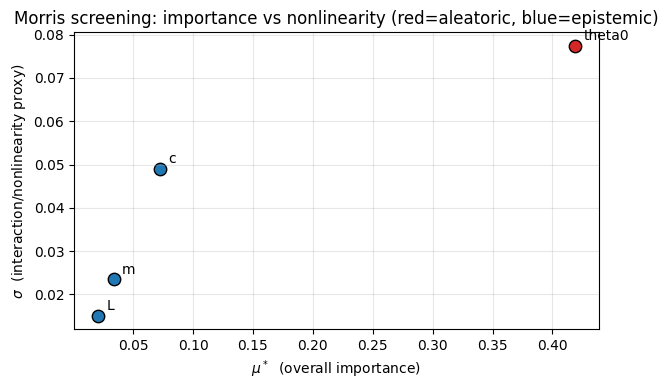

In [18]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))
for name in pendulum_dists:
    color = kind_color[pendulum_dists[name].kind]
    ax.scatter(morris[name]["mu_star"], morris[name]["sigma"],
               s=80, color=color, edgecolor="k")
    ax.annotate(name,
                (morris[name]["mu_star"], morris[name]["sigma"]),
                xytext=(6, 4), textcoords="offset points", fontsize=10)
ax.set_xlabel(r"$\mu^*$  (overall importance)")
ax.set_ylabel(r"$\sigma$  (interaction/nonlinearity proxy)")
ax.set_title("Morris screening: importance vs nonlinearity (red=aleatoric, blue=epistemic)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

*Figure 8.* The Morris $(\mu^*, \sigma)$ scatter. Points to the right are more important; points high up exhibit larger interaction/nonlinearity. The ranking by $\mu^*$ agrees with the Sobol $S_T$ ranking from Section 6 at a fraction of the simulation cost &mdash; the standard argument for using Morris as a cheap screening pass before paying for the full Sobol budget. The aleatoric input ($\theta_0$, red) sits well to the right, consistent with its dominant total-order index.

## 9. From variance to design margin: VaR and CVaR

A variance budget tells you how spread out the QoI is; a *risk* number tells you how bad the bad case is. For sizing a stop or a clearance, we want the worst-end quantile and the expected severity beyond it.

We use the convention that &ldquo;low is bad&rdquo; for negative-quantity QoIs and &ldquo;high is bad&rdquo; for stress / amplitude QoIs. Our pendulum QoI is the latter &mdash; bigger swings are worse for a safety-margin design &mdash; so we ask for the 95th percentile of $Y$ and the mean of the upper 5% tail. The `value_at_risk` / `conditional_value_at_risk` helpers operate on the *left* tail by convention, so we feed them $-Y$ and negate the result to recover the upper-tail summary.

In [19]:
# Use the high-N IID sample for a tight tail estimate.
alpha = 0.05  # we want the top 5% of swing amplitudes
var_lower = value_at_risk(-iid_qoi, alpha=alpha)            # 5th percentile of -Y
cvar_lower = conditional_value_at_risk(-iid_qoi, alpha=alpha)
var_upper = -var_lower
cvar_upper = -cvar_lower
print(f"Top-5%   VaR (upper-tail threshold): {var_upper:.4f} rad ({np.degrees(var_upper):.2f} deg)")
print(f"Top-5%  CVaR (mean of upper 5% tail): {cvar_upper:.4f} rad ({np.degrees(cvar_upper):.2f} deg)")
print(f"Nominal QoI: {float(rms_angle(nominal_params)):.4f} rad")
print(
    f"\nDesign margin: a fixture sized to {np.degrees(cvar_upper):.1f}deg of "
    f"RMS swing absorbs the average top-5% case under the current uncertainty budget."
)

Top-5%   VaR (upper-tail threshold): 0.3687 rad (21.13 deg)
Top-5%  CVaR (mean of upper 5% tail): 0.4054 rad (23.23 deg)
Nominal QoI: 0.2938 rad

Design margin: a fixture sized to 23.2deg of RMS swing absorbs the average top-5% case under the current uncertainty budget.


## 10. Failure modes &mdash; when this approach breaks down

Three regimes where the workflow above stops being useful and you should reach for something heavier.

- **Strong interactions.** When the interaction share $I_{\mathrm{a}\times \mathrm{e}}$ approaches half of $\mathrm{Var}(Y)$ the two-group ANOVA loses its punch &mdash; you can no longer cleanly attribute variance to aleatoric or epistemic origin because the bulk lives in the cross-term. Diagnostic: $I / \mathrm{Var}(Y) > 0.3$. Fix: condition aleatoric on epistemic via `conditional_monte_carlo` (a double-loop estimator) and report the variance of the inner aleatoric distribution as a function of the outer epistemic draw.
- **Non-smooth QoIs.** The QMC convergence advantage (Section 5) requires the integrand to be smooth in every input. Threshold events (a swing that crosses an obstacle), hard saturations, and event-driven hybrids all degrade QMC back toward $\mathcal{O}(N^{-1/2})$. Diagnostic: re-run Section 5 with the smoothness-breaking element added &mdash; if Sobol stops beating IID, the smoothness assumption has snapped. Fix: stick to LHS, or use a kink-aware QMC scheme outside the library.
- **Rare-event tails.** Section 9&rsquo;s VaR / CVaR is an *empirical* quantile on $N$ samples; for very small $\alpha$ (1-in-10k events) it has terrible relative variance. Diagnostic: tail counts $\le 10$. Fix: importance sampling via `importance_sample` &mdash; draw from a heavier-tailed proposal that covers the bad region and reweight.

## Exercises

1. **Re-tagging.** Suppose your finance department buys a $0.1 mg$ balance and a $0.01 mm$ caliper. Re-tag $m$ and $L$ as `aleatoric` (their residual uncertainty is now noise-floor-limited) and re-run the headline decomposition. How does the aleatoric share change? Is the variance share story now mostly about $\theta_0$ + $c$?
2. **Tighter release jig.** Halve `Normal.scale` on $\theta_0$ (a tighter release mechanism). What is the new $V_a$? Does $V_e$ change at all? If yes, why &mdash; the epistemic distributions weren&rsquo;t touched? (Hint: the *share* depends on the *total*, so reducing aleatoric variance changes the denominator.)
3. **Bootstrap CIs on the decomposition.** Wrap `decompose_variance_sobol` in a loop over 30 independent PRNG keys, gather the resulting `(V_a, V_e, I)` triples, and report the 5th/95th percentile of each share. Where are the wide bands and where are the tight ones?
4. **A non-smooth QoI.** Replace `rms_angle` with `peak_angle` that returns $\max_t |\theta(t)|$. This is still smooth in the four inputs (the max is differentiable almost everywhere), but the corresponding integrand is less regular than RMS. Re-run Section 5 &mdash; does QMC still beat LHS at $N=128$?
5. **Open-ended: minimum-cost variance reduction.** Suppose each &ldquo;unit of metrology&rdquo; costs USD 1k and halves one epistemic parameter&rsquo;s scale. Given a budget of USD 3k, which three half-spend choices minimise the expected $V_e$? You will need a small loop that simulates the decomposition under each candidate spend and picks the lowest. (This is a sensitivity-driven design-of-experiments problem; the variance shares from Section 7 are the input you need.)

## Key takeaways

- `jaxonomy.uq` tags every `Distribution` with a `kind` (`"aleatoric"` or `"epistemic"`); `split_distributions_by_kind` and the `_sobol`/Taylor decompositions consume that tag with no manual bookkeeping.
- `sobol_indices` matches the Ishigami closed form to better than 0.01 at $N=8192$; on the pendulum at $N=512$ it cleanly ranks the four inputs and surfaces the interaction structure.
- LHS reduces the mean-estimator variance by an order of magnitude at the same $N$ as IID on smooth QoIs; scrambled-Sobol QMC reduces it further still.
- `decompose_variance_sobol` takes only $4N$ evaluations regardless of how many parameters are in each group &mdash; the indices are *grouped*, not per-parameter.
- Variance shares are *point estimates*: wrap in a bootstrap loop if you&rsquo;re going to spend money on the answer.
- `value_at_risk` / `conditional_value_at_risk` connect the variance budget to a concrete design-margin number.

## Where to next

- [Engine map fitting to MPC](engine_map_fitting_to_mpc.ipynb) &mdash; the same `jaxonomy.uq` distributions can describe parameter dispersion on a fitted lookup table, with `jax.grad` flowing through the closed-loop cost end-to-end.
- [PID auto-tuning with sensitivity constraints](pid_autotuning_interactive.ipynb) &mdash; once you have a variance budget you typically want to push the controller against it; that notebook closes the loop.
- [Returning rocket booster GNC validation](booster_part_6_gnc_validation_and_analysis.ipynb) &mdash; the full-scale Monte Carlo dispersion case study, with thousands of trials of a realistic GNC stack.

## References

- Ishigami, T., & Homma, T. (1990). *An importance quantification technique in uncertainty analysis for computer models.* First International Symposium on Uncertainty Modeling and Analysis.
- Saltelli, A. (2002). *Making best use of model evaluations to compute sensitivity indices.* Computer Physics Communications, 145(2), 280-297.
- Jansen, M. J. W. (1999). *Analysis of variance designs for model output.* Computer Physics Communications, 117(1-2), 35-43.
- Morris, M. D. (1991). *Factorial sampling plans for preliminary computational experiments.* Technometrics, 33(2), 161-174.
- Owen, A. B. (1997). *Scrambled net variance for integrals of smooth functions.* Annals of Statistics, 25(4), 1541-1562.
- Der Kiureghian, A., & Ditlevsen, O. (2009). *Aleatory or epistemic? Does it matter?* Structural Safety, 31(2), 105-112.